# **PROJECT 2: FINE-TUNING DEEPSEEK-OCR WITH VIETNAMESE DATASET**
**Course:** Introduction to Natural Language Processing (Fall 2025)
**University:** VNU-HCM University of Science
**Lecturer:** PhD. Nguyen Hong Buu Long

---

### **Student Information**
* **Full Name:** Nguyen Hai Dang
* **Student ID:** 23127165
* **Email:** nhdang231@clc.fitus.edu.vn

### **Project Overview**
* **Objective:** Fine-tune the **DeepSeek-OCR** ​​model using **LoRA (Low-Rank Adaptation)** to improve Vietnamese handwriting recognition.
* **Dataset:** UIT-HWDB (Handwritten Vietnamese Database).
* **Tools:** Unsloth (Optimization), Hugging Face Transformers, PyTorch.

* **Hardware:** Google Colab T4 GPU (16GB VRAM).

---
### **Table of Contents**
1. **Environment Setup**: Install libraries and prepare the GPU.

2. **Task 2.1 - Data Preparation**: Process UIT-HWDB data, split the set into Train/Val/Test sets.

3. **Task 2.3 - Baseline Evaluation**: Evaluate the base model before training.

4. **Task 2.2 - Fine-tuning**: Configure LoRA and train the model.

5. **Task 2.4 - Final Evaluation**: Evaluate and compare results after training.

## **1. Environment Setup**
Set up the necessary environment and libraries. Use **Unsloth** to optimize memory usage and training speed.

In [1]:
# @title 1. Environment Installation & Setup
# Installing Unsloth and supporting libraries for the DeepSeek-OCR model
# Using %%capture to hide installation logs for a cleaner notebook.
%%capture
import os, re
import torch

# 1. Install Unsloth & Dependencies
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Check torch version to install correct xformers
    v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth

# 2. Install Standard Libraries
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install jiwer  # Character Error Rate (CER) Calculation Library
!pip install einops addict easydict

# 3. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 4. Define Paths
# Note: Ensure you upload the dataset to the correct RAW_DATA_DIR path.
RAW_DATA_DIR = "/content/drive/MyDrive/NLP/dataset/UIT_HWDB_line"
PROCESSED_DATA_DIR = "/content/drive/MyDrive/NLP/data"   # Location where processed data is stored
OUTPUT_MODEL_DIR = "/content/drive/MyDrive/NLP/models/deepseek_ocr_lora" # Location where model is stored

# Check GPU
gpu_stats = torch.cuda.get_device_properties(0)
print(f"✅ GPU Setup Complete: {gpu_stats.name} ({round(gpu_stats.total_memory / 1024**3, 2)} GB VRAM)")

---

## **2. Data Preparation & Processing**
According to the requirements of section 2.1 of the Project:
1. Collect data from **UIT-HWDB**.

2. Normalize and convert to `ImageFolder` format (including images and the `metadata.jsonl` file) for compatibility with HuggingFace Datasets.

3. Split the dataset: **Train (90%), Validation (10%)** and **Test** independently.

## **2. Task 2.1: Data Preparation & Processing**
According to the project requirements, we need to:
1. Collect Vietnamese data (using **UIT-HWDB**).

2. Preprocess and convert to `ImageFolder` format (including images and the `metadata.jsonl` file) for compatibility with HuggingFace Datasets.

3. Divide the dataset: **Train (90%)**, **Validation (10%)**, and keep the **Test** set separate.

> **Note:** The code below will scan the dataset folder, read the JSON label file, and copy images to a new folder with the standard structure.

In [2]:
import os
import json
import shutil
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

def collect_raw_data(root_path, subset_name, limit=None):
    """
    Function to scan the raw data directory UIT-HWDB and read labels from the label.json file
    """
    items = []
    full_path = os.path.join(root_path, subset_name)
    if not os.path.exists(full_path):
        print(f"⚠️ Warning: Path not found: {full_path}")
        return []

    folders = sorted([f for f in os.listdir(full_path) if os.path.isdir(os.path.join(full_path, f))],
                     key=lambda x: int(x) if x.isdigit() else x)

    if limit: folders = folders[:limit] # Limit the number of folders if you need to do quick testing.

    print(f"-> Scanning {len(folders)} folders in {subset_name}...")
    for folder in tqdm(folders, desc="Reading Folders"):
        folder_path = os.path.join(full_path, folder)
        json_file = os.path.join(folder_path, "label.json")

        if os.path.exists(json_file):
            try:
                with open(json_file, 'r', encoding='utf-8') as f: labels = json.load(f)
                for img_name, text in labels.items():
                    src_path = os.path.join(folder_path, img_name)
                    if os.path.exists(src_path):
                        items.append({
                            "src_path": src_path,
                            "file_name": f"{folder}_{img_name}",
                            "text": text
                        })
            except Exception as e:
                print(f"Error reading {json_file}: {e}")
    return items

def save_subset(items, dest_root, subset_name):
    """
    Hàm lưu dataset theo chuẩn HuggingFace ImageFolder
    """
    subset_dir = os.path.join(dest_root, subset_name)
    os.makedirs(subset_dir, exist_ok=True)
    metadata_lines = []

    print(f"-> Saving {subset_name} ({len(items)} images)...")
    for item in tqdm(items, desc=f"Writing {subset_name}"):
        # Copy image
        shutil.copy2(item['src_path'], os.path.join(subset_dir, item['file_name']))
        # Create metadata
        metadata_lines.append(json.dumps({"file_name": item['file_name'], "text": item['text']}, ensure_ascii=False))

    # Write file metadata.jsonl
    with open(os.path.join(subset_dir, "metadata.jsonl"), 'w', encoding='utf-8') as f:
        f.write('\n'.join(metadata_lines))

# --- MAIN DATA PIPELINE ---
if not os.path.exists(PROCESSED_DATA_DIR) or not os.listdir(PROCESSED_DATA_DIR):
    print("🔄 Starting Data Processing...")

    # 1. Data Collection (Sample for demo if dataset is too large)
    # limit=249 folders for training, limit=6 folders for testing (full)
    raw_train = collect_raw_data(RAW_DATA_DIR, "train_data", limit=249)
    raw_test = collect_raw_data(RAW_DATA_DIR, "test_data", limit=6)

    # 2. Split Train/Validation (90/10 split)
    train_items, val_items = train_test_split(raw_train, test_size=0.1, random_state=42)

    # 3. Save processed data
    save_subset(train_items, PROCESSED_DATA_DIR, "train")
    save_subset(val_items, PROCESSED_DATA_DIR, "validation")
    save_subset(raw_test, PROCESSED_DATA_DIR, "test")

    print(f"✅ Data processing complete. Saved to: {PROCESSED_DATA_DIR}")
else:
    print(f"✅ Data already exists at: {PROCESSED_DATA_DIR}")

🔄 Starting Data Processing...
-> Scanning 249 folders in train_data...


Reading Folders:   0%|          | 0/249 [00:00<?, ?it/s]

-> Scanning 6 folders in test_data...


Reading Folders:   0%|          | 0/6 [00:00<?, ?it/s]

-> Saving train (6325 images)...


...

-> Saving validation (703 images)...


Writing validation:   0%|          | 0/703 [00:00<?, ?it/s]

-> Saving test (201 images)...


Writing test:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Data processing complete. Saved to: /content/drive/MyDrive/NLP/data


---

## **3. Model Initialization & Baseline Evaluation**
To save GPU memory (T4 16GB), we use **Unsloth** to load the **DeepSeek-OCR** ​​model in **4-bit quantization** mode.

**Configuration:**
* **Model:** `unsloth/DeepSeek-OCR` (or the equivalent Qwen-VL variant).

* **Quantization:** 4-bit (reduces VRAM, significantly maintains performance).

### 3.1. Load Model

In [3]:
from huggingface_hub import snapshot_download
snapshot_download("unsloth/DeepSeek-OCR", local_dir = "deepseek_ocr")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 21 files:   0%|          | 0/21 [00:00<?, ?it/s]

README.md: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

LICENSE: 0.00B [00:00, ?B/s]

...

processor_config.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

'/content/deepseek_ocr'

In [4]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch
from transformers import AutoModel
import os
os.environ["UNSLOTH_WARN_UNINITIALIZED"] = '0'
# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Qwen3-VL-8B-Instruct-bnb-4bit", # Qwen 3 vision support
    "unsloth/Qwen3-VL-8B-Thinking-bnb-4bit",
    "unsloth/Qwen3-VL-32B-Instruct-bnb-4bit",
    "unsloth/Qwen3-VL-32B-Thinking-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastVisionModel.from_pretrained(
    "./deepseek_ocr",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    auto_model = AutoModel,
    trust_remote_code=True,
    unsloth_force_compile=True,
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

print("✅ Model loaded successfully.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2025.12.7: Fast Deepseekocr patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at ./deepseek_ocr and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded successfully.


### 3.2. Define Robust Inference Function (Fixes old code errors)
This function replaces `model.infer` (which often has NoneType errors) to ensure accurate predictions.

In [5]:
from deepseek_ocr.modeling_deepseekocr import BasicImageTransform, dynamic_preprocess, text_encode
from PIL import Image, ImageOps
import math

# This function replaces the default model.infer() to handle cropped images and provide a more stable prompt.
def predict_manual(model, tokenizer, image, prompt="<image>\nOCR tiếng Việt."):
    """
    Perform OCR on an input image.
    Input: Image (PIL), Prompt
    Output: Text string
    """
    if image.mode != "RGB":
        image = image.convert("RGB")

    # DeepSeek-OCR Image Processing Parameters
    image_size, base_size, patch_size, downsample_ratio = 640, 1024, 16, 4
    image_transform = BasicImageTransform(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5), normalize=True)
    dtype = model.dtype
    device = model.device

    # Dynamic Preprocessing (Crop images if needed)
    if image.size[0] <= 640 and image.size[1] <= 640:
        crop_ratio = (1, 1); images_crop_raw = []
    else:
        images_crop_raw, crop_ratio = dynamic_preprocess(image, min_num=2, max_num=9, image_size=image_size, use_thumbnail=False)

    # Prepare input tensor
    images_list = []
    global_view = ImageOps.pad(image, (base_size, base_size), color=(128, 128, 128))
    images_list.append(image_transform(global_view).to(dtype))

    images_crop_list = []
    if crop_ratio[0] > 1 or crop_ratio[1] > 1:
        for crop_img in images_crop_raw:
            images_crop_list.append(image_transform(crop_img).to(dtype))

    # Tokenize input
    input_ids = [tokenizer.bos_token_id]
    image_token_id = 128815 # Special token for image

    # Calculate number of token placeholder for image
    num_queries = math.ceil((image_size // patch_size) / downsample_ratio)
    num_queries_base = math.ceil((base_size // patch_size) / downsample_ratio)

    tokenized_image = ([image_token_id] * num_queries_base + [image_token_id]) * num_queries_base + [image_token_id]
    if crop_ratio[0] > 1 or crop_ratio[1] > 1:
        tokenized_image += ([image_token_id] * (num_queries * crop_ratio[0]) + [image_token_id]) * (num_queries * crop_ratio[1])

    user_tokens = text_encode(tokenizer, prompt.replace("<image>", ""), bos=False, eos=False)
    input_ids.extend(tokenized_image)
    input_ids.extend(user_tokens)
    input_ids.extend(text_encode(tokenizer, "\n", bos=False, eos=False))

    input_ids = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)
    images_ori = torch.stack(images_list, dim=0).to(device)

    if images_crop_list:
        images_crop = torch.stack(images_crop_list, dim=0).to(device)
    else:
        images_crop = torch.zeros((1, 3, base_size, base_size), dtype=dtype).to(device)

    images_spatial_crop = torch.tensor([crop_ratio], dtype=torch.long).to(device)

    # Generate Text
    with torch.inference_mode():
        images_seq_mask = torch.tensor(
            [token == image_token_id for token in input_ids[0]],
            dtype=torch.bool, device=device
        ).unsqueeze(0)

        outputs = model.generate(
            input_ids=input_ids,
            images=[(images_crop, images_ori)],
            images_seq_mask=images_seq_mask.unsqueeze(0),
            images_spatial_crop=images_spatial_crop,
            max_new_tokens=256,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            do_sample=False, # Greedy decoding for the best results
            use_cache=True
        )

    generated_ids = outputs[0][input_ids.shape[1]:]
    text = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return text.strip()

### **3.3. Baseline Evaluation (Before Fine-tune)**
We will quickly evaluate the performance of the original model on the test set using the **CER (Character Error Rate)** metric. This helps establish a benchmark for comparison.

In [6]:
from datasets import load_dataset
import jiwer
import random
import matplotlib.pyplot as plt

# Load Test Set
dataset = load_dataset("imagefolder", data_dir=PROCESSED_DATA_DIR)
test_dataset = dataset['test']

Resolving data files:   0%|          | 0/6326 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/704 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/202 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [7]:
test_dataset[0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=L size=2048x172>,
 'text': 'Thứ trưởng Bộ Tài nguyên & môi trường Đặng Hùng Võ tâm đắc với'}

--- EVALUATING BASELINE MODEL ---
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])

Example 1:
🖼️ Image Size: (2048, 172)
📝 GT   : Thứ trưởng Bộ Tài nguyên & môi trường Đặng Hùng Võ tâm đắc với
🤖 Pred : Thiết thứ Bộ tài nguyên và môi trường Đảng Hưng Vô tâm đạo vị.
📊 CER  : 0.2742


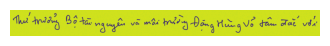

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])

Example 2:
🖼️ Image Size: (2048, 139)
📝 GT   : cơ chế " khuyến khích nhà đầu tư thỏa thuận với người sử dụng đất để nhận
🤖 Pred : có thể "không kiếc, mà sẵn từ thỏa thuận với người sửa đổi thêm
📊 CER  : 0.4110


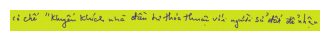

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])

Example 3:
🖼️ Image Size: (2048, 167)
📝 GT   : chuyển nhượng hoặc thuê quyền sử dụng đất, nhận góp vốn bằng quyền sử
🤖 Pred : chuyên những hoặc thực quyền sử dụng đất, nhà góp vốn bảng quyền sử
📊 CER  : 0.1159


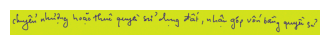

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])

Example 4:
🖼️ Image Size: (2048, 139)
📝 GT   : dụng đất... " Nhưng tại hội nghị hôm qua, tiếng nói từ các sở tài nguyên
🤖 Pred : dùng đặt ... " Mừng tại hòa nghĩa hôm qua, tiếng Việt là cái gì sao tôi nguyện
📊 CER  : 0.3333


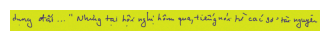

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])

Example 5:
🖼️ Image Size: (2048, 144)
📝 GT   : & môi trường lại đều đồng thanh " loại bỏ " điều khoản này ra khỏi dự thảo.
🤖 Pred : Vài môi truyền thông, lưu thích nhau. "You bo!" điều không ngờ nói chút điều đó.
📊 CER  : 0.6267


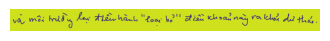

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])

=> 🔴 Average Baseline CER: 0.3040


In [8]:
print("--- EVALUATING BASELINE MODEL ---")
FastVisionModel.for_inference(model) # Switch the model to Inference mode.

baseline_cers = []
samples_to_show = 5 # Number of samples printed to the screen

for i in range(len(test_dataset)):
    if i >= 10: break # Quick evaluation of the first 10 samples to save time.

    sample = test_dataset[i]
    ground_truth = sample['text']
    image = sample['image']

    # Predict
    pred = predict_manual(model, tokenizer, image)

    # Calculate CER
    error = jiwer.cer(ground_truth, pred)
    baseline_cers.append(error)

    if i < samples_to_show:
        print(f"\nExample {i+1}:")
        print(f"🖼️ Image Size: {image.size}")
        print(f"📝 GT   : {ground_truth}")
        print(f"🤖 Pred : {pred}")
        print(f"📊 CER  : {error:.4f}")

        plt.figure(figsize=(4, 2))
        plt.imshow(image)
        plt.axis('off')
        plt.show()

avg_baseline_cer = sum(baseline_cers)/len(baseline_cers)
print(f"\n=> 🔴 Average Baseline CER: {avg_baseline_cer:.4f}")

---

## **4. Task 2.2: Fine-tuning Strategy**
We use **LoRA (Low-Rank Adaptation)** to fine-tune the model. This is an optimal method for training large models on a limited GPU by updating only a small portion of the parameters (adapters).

**Configuration:**
* **Target Modules:** `q_proj`, `v_proj`,... (Attention classes of Vision & Language Model).

* **Rank (r):** 16.

* **Batch Size:** 1 (combined with Gradient Accumulation = 8 to simulate batch size 8).

### 4.1. LoRA Configuration

In [9]:
model = FastVisionModel.get_peft_model(
    model,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
)
print("✅ LoRA Adapters attached.")

Unsloth: Making `model.base_model.model.model` require gradients
✅ LoRA Adapters attached.


### 4.2. Data Processing & Collator (Padding/Dimension Error Fix)
This section is extremely important. This Data Collator has been fixed to prevent `IndexError` and `RuntimeError` compared to the original version.

In [10]:
# Convert dataset to conversational format (but keep PIL images)
instruction = "<image>\nOCR tiếng Việt."
def format_data(sample):
    return {
        "messages": [
            {"role": "<|User|>", "content": instruction, "images": [sample["image"]]},
            {"role": "<|Assistant|>", "content": sample["text"]}
        ]
    }

# Use List Comprehension to keep the PIL Image object in RAM.
formatted_train = [format_data(s) for s in dataset['train']]
formatted_val = [format_data(s) for s in dataset['validation']]

# --- FIX DATA COLLATOR ---
from dataclasses import dataclass
from typing import Dict, List, Any
from torch.nn.utils.rnn import pad_sequence

import torch
import math
import io
from dataclasses import dataclass
from typing import Dict, List, Any, Tuple
from PIL import Image, ImageOps
from torch.nn.utils.rnn import pad_sequence

from deepseek_ocr.modeling_deepseekocr import (
    text_encode,
    BasicImageTransform,
    dynamic_preprocess,
)

@dataclass
class DeepSeekOCRDataCollator:
    tokenizer: Any
    model: Any
    image_size: int = 640
    base_size: int = 1024
    crop_mode: bool = True
    image_token_id: int = 128815
    train_on_responses_only: bool = True


    def __init__(
        self,
        tokenizer,
        model,
        image_size: int = 640,
        base_size: int = 1024,
        crop_mode: bool = True,
        train_on_responses_only: bool = True,
    ):
        self.tokenizer = tokenizer
        self.model = model
        self.image_size = image_size
        self.base_size = base_size
        self.crop_mode = crop_mode
        self.image_token_id = 128815
        self.dtype = model.dtype
        self.train_on_responses_only = train_on_responses_only

        self.image_transform = BasicImageTransform(
            mean=(0.5, 0.5, 0.5),
            std=(0.5, 0.5, 0.5),
            normalize=True,
        )

        self.patch_size = 16
        self.downsample_ratio = 4

        if hasattr(tokenizer, "bos_token_id") and tokenizer.bos_token_id is not None:
            self.bos_id = tokenizer.bos_token_id
        else:
            self.bos_id = 0
            print("Warning: tokenizer has no bos_token_id, using 0")


    def deserialize_image(self, image_data) -> Image.Image:
        if isinstance(image_data, Image.Image):
            return image_data.convert("RGB")
        elif isinstance(image_data, dict) and "bytes" in image_data:
            return Image.open(io.BytesIO(image_data["bytes"])).convert("RGB")
        else:
            raise ValueError(f"Unsupported image format: {type(image_data)}")


    def process_image(
        self, image: Image.Image
    ) -> Tuple[List, List, List, List, Tuple[int, int]]:
        images_list = []
        images_crop_list = []
        images_spatial_crop = []

        if self.crop_mode:
            if image.size[0] <= 640 and image.size[1] <= 640:
                crop_ratio = (1, 1)
                images_crop_raw = []
            else:
                images_crop_raw, crop_ratio = dynamic_preprocess(
                    image,
                    min_num=2,
                    max_num=9,
                    image_size=self.image_size,
                    use_thumbnail=False,
                )

            global_view = ImageOps.pad(
                image,
                (self.base_size, self.base_size),
                color=tuple(int(x * 255) for x in self.image_transform.mean),
            )
            images_list.append(self.image_transform(global_view).to(self.dtype))

            width_crop_num, height_crop_num = crop_ratio
            images_spatial_crop.append([width_crop_num, height_crop_num])

            if width_crop_num > 1 or height_crop_num > 1:
                for crop_img in images_crop_raw:
                    images_crop_list.append(
                        self.image_transform(crop_img).to(self.dtype)
                    )

            num_queries = math.ceil(
                (self.image_size // self.patch_size) / self.downsample_ratio
            )
            num_queries_base = math.ceil(
                (self.base_size // self.patch_size) / self.downsample_ratio
            )

            tokenized_image = (
                ([self.image_token_id] * num_queries_base + [self.image_token_id])
                * num_queries_base
            )
            tokenized_image += [self.image_token_id]

            if width_crop_num > 1 or height_crop_num > 1:
                tokenized_image += (
                    ([self.image_token_id] * (num_queries * width_crop_num) + [self.image_token_id])
                    * (num_queries * height_crop_num)
                )

        else:
            crop_ratio = (1, 1)
            images_spatial_crop.append([1, 1])

            if self.base_size <= 640:
                image = image.resize((self.base_size, self.base_size), Image.LANCZOS)
            else:
                image = ImageOps.pad(
                    image,
                    (self.base_size, self.base_size),
                    color=tuple(int(x * 255) for x in self.image_transform.mean),
                )

            images_list.append(self.image_transform(image).to(self.dtype))

            num_queries = math.ceil(
                (self.base_size // self.patch_size) / self.downsample_ratio
            )
            tokenized_image = (
                ([self.image_token_id] * num_queries + [self.image_token_id])
                * num_queries
            )
            tokenized_image += [self.image_token_id]

        return (
            images_list,
            images_crop_list,
            images_spatial_crop,
            tokenized_image,
            crop_ratio,
        )


    def process_single_sample(self, messages: List[Dict]) -> Dict[str, Any]:
        images = []
        for msg in messages:
            if "images" in msg and msg["images"]:
                for img in msg["images"]:
                    if img is not None:
                        images.append(self.deserialize_image(img))

        if not images:
            raise ValueError("No images found in sample")

        tokenized_str = []
        images_seq_mask = []
        images_list, images_crop_list, images_spatial_crop = [], [], []

        prompt_token_count = -1
        assistant_started = False
        image_idx = 0

        tokenized_str.append(self.bos_id)
        images_seq_mask.append(False)

        for msg in messages:
            role = msg["role"]
            content = msg["content"]

            if role == "<|Assistant|>":
                if not assistant_started:
                    prompt_token_count = len(tokenized_str)
                    assistant_started = True
                content = f"{content.strip()} {self.tokenizer.eos_token}"

            splits = content.split("<image>")
            for i, text in enumerate(splits):
                toks = text_encode(self.tokenizer, text, bos=False, eos=False)
                tokenized_str.extend(toks)
                images_seq_mask.extend([False] * len(toks))

                if i < len(splits) - 1:
                    if image_idx >= len(images):
                        raise ValueError("Found <image> token but no image provided")

                    img_list, crop_list, spatial_crop, tok_img, _ = self.process_image(
                        images[image_idx]
                    )
                    images_list.extend(img_list)
                    images_crop_list.extend(crop_list)
                    images_spatial_crop.extend(spatial_crop)

                    tokenized_str.extend(tok_img)
                    images_seq_mask.extend([True] * len(tok_img))
                    image_idx += 1

        if image_idx != len(images):
            raise ValueError("Number of images does not match <image> tokens")

        if not assistant_started:
            prompt_token_count = len(tokenized_str)

        images_ori = torch.stack(images_list, dim=0)
        images_spatial_crop = torch.tensor(images_spatial_crop, dtype=torch.long)

        if images_crop_list:
            images_crop = torch.stack(images_crop_list, dim=0)
        else:
            images_crop = torch.zeros(
                (1, 3, self.base_size, self.base_size), dtype=self.dtype
            )

        return {
            "input_ids": torch.tensor(tokenized_str, dtype=torch.long),
            "images_seq_mask": torch.tensor(images_seq_mask, dtype=torch.bool),
            "images_ori": images_ori,
            "images_crop": images_crop,
            "images_spatial_crop": images_spatial_crop,
            "prompt_token_count": prompt_token_count,
        }


    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        batch_data = []

        for feat in features:
            try:
                batch_data.append(
                    self.process_single_sample(feat["messages"])
                )
            except Exception as e:
                print(f"Skip bad sample: {e}")

        if not batch_data:
            raise ValueError("No valid samples in batch")

        input_ids = pad_sequence(
            [b["input_ids"] for b in batch_data],
            batch_first=True,
            padding_value=self.tokenizer.pad_token_id,
        )
        images_seq_mask = pad_sequence(
            [b["images_seq_mask"] for b in batch_data],
            batch_first=True,
            padding_value=False,
        )

        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        labels[images_seq_mask] = -100

        if self.train_on_responses_only:
            for i, b in enumerate(batch_data):
                if b["prompt_token_count"] > 0:
                    labels[i, : b["prompt_token_count"]] = -100

        attention_mask = (input_ids != self.tokenizer.pad_token_id).long()

        images_batch = [
            (b["images_crop"], b["images_ori"]) for b in batch_data
        ]
        images_spatial_crop = torch.cat(
            [b["images_spatial_crop"] for b in batch_data], dim=0
        )

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "images": images_batch,
            "images_seq_mask": images_seq_mask,
            "images_spatial_crop": images_spatial_crop,
        }

### 4.3. Trainer Configuration and Execution
Setting optimal training parameters for the T4 GPU.

In [11]:
from transformers import Trainer, TrainingArguments
from unsloth import is_bf16_supported

FastVisionModel.for_training(model)

data_collator = DeepSeekOCRDataCollator(tokenizer=tokenizer, model=model)

trainer = Trainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = data_collator,
    train_dataset = formatted_train,
    eval_dataset = formatted_val,
    args = TrainingArguments(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 8,
        per_device_eval_batch_size = 1,
        warmup_steps = 10,
        max_steps = 90,
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = OUTPUT_MODEL_DIR,
        save_strategy = "steps",
        save_steps = 30,
        eval_strategy = "steps",
        eval_steps = 30,
        fp16 = not is_bf16_supported(),
        bf16 = is_bf16_supported(),
        remove_unused_columns = False,
        report_to = "none",
        load_best_model_at_end = True,
        dataloader_persistent_workers = False,

    ),
)

/tmp/ipython-input-854548649.py:8: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer._unsloth___init__`. Use `processing_class` instead.
  trainer = Trainer(


In [12]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
4.512 GB of memory reserved.


In [13]:
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

print("🚀 Starting Fine-tuning...")
trainer_stats = trainer.train()

🚀 Starting Fine-tuning...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 6,325 | Num Epochs = 1 | Total steps = 90
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 77,509,632 of 3,413,615,872 (2.27% trained)
Unsloth: Not an error, but DeepseekOCRForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
Unsloth: Will smartly offload gradients to save VRAM!
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])


Step,Training Loss,Validation Loss
30,1.019800,0.874294
60,0.664900,0.785732
90,0.905400,0.750494


BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([6, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([8, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE: 

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE: 

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([8, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])
BASE: 

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


---

## **5. Task 2.4: Results & Discussion**
After fine-tuning, we will review the results on the test set (independently) to see the level of improvement.

--- EVALUATING FINE-TUNED MODEL ---
BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])

Example 1:
📝 GT   : Thứ trưởng Bộ Tài nguyên & môi trường Đặng Hùng Võ tâm đắc với
🤖 Pred : Thứ trưởng Bộ tài nguyên và môi trường Đảng Hưng Vô tâm đã đề với
📊 CER  : 0.1613


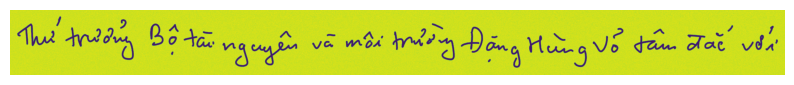

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])

Example 2:
📝 GT   : cơ chế " khuyến khích nhà đầu tư thỏa thuận với người sử dụng đất để nhận
🤖 Pred : có chế " khuyến khích, mà đã từ hóa thuốc và người sử đã để nhân
📊 CER  : 0.2877


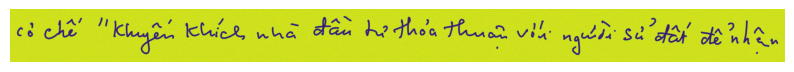

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])

Example 3:
📝 GT   : chuyển nhượng hoặc thuê quyền sử dụng đất, nhận góp vốn bằng quyền sử
🤖 Pred : chuyển những hoặc thực quyền sử dụng đất, nhằm góp vốn bảng quyền sử
📊 CER  : 0.1014


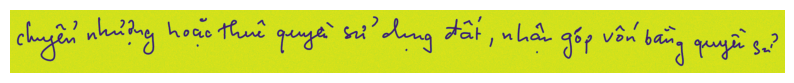

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])

Example 4:
📝 GT   : dụng đất... " Nhưng tại hội nghị hôm qua, tiếng nói từ các sở tài nguyên
🤖 Pred : dụng đất... " Nhưng tại hội nghị hôm qua, tiếng nói: họ cà cà sò tù nguyên
📊 CER  : 0.1250


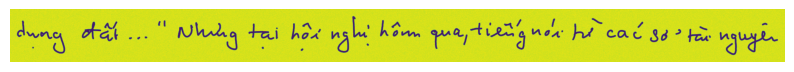

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])

Example 5:
📝 GT   : & môi trường lại đều đồng thanh " loại bỏ " điều khoản này ra khỏi dự thảo.
🤖 Pred : và mỗi trường lên tiến hành " toạ bộ " điều khoản này ra khỏi địa địa.
📊 CER  : 0.3200


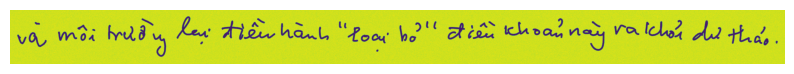

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])


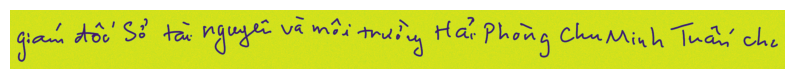

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])


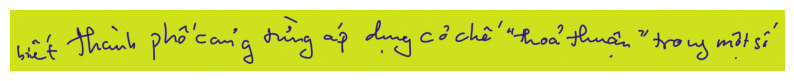

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])


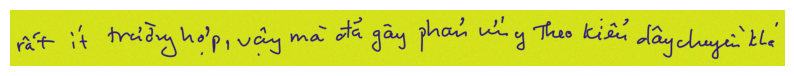

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])


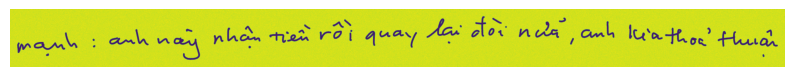

BASE:  torch.Size([1, 256, 1280])
PATCHES:  torch.Size([9, 100, 1280])


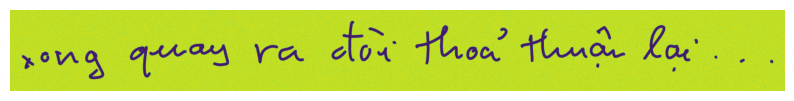


=> 🟢 Average Fine-tuned CER: 0.2002

=== FINAL REPORT ===
Original CER   : 0.3040
Fine-tuned CER : 0.2002
Improvement    : 0.1038 (Lower CER is better)


In [14]:
FastVisionModel.for_inference(model)

print("--- EVALUATING FINE-TUNED MODEL ---")
finetuned_cers = []
samples_to_show = 5

for i in range(len(test_dataset)):
    if i >= 10: break
    sample = test_dataset[i]
    ground_truth = sample['text']
    image = sample['image']

    pred = predict_manual(model, tokenizer, image)
    error = jiwer.cer(ground_truth, pred)
    finetuned_cers.append(error)

    if i < samples_to_show:
        print(f"\nExample {i+1}:")
        print(f"📝 GT   : {ground_truth}")
        print(f"🤖 Pred : {pred}")
        print(f"📊 CER  : {error:.4f}")

    plt.figure(figsize=(10, 3))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

avg_finetuned_cer = sum(finetuned_cers)/len(finetuned_cers)
print(f"\n=> 🟢 Average Fine-tuned CER: {avg_finetuned_cer:.4f}")

# Compare
improvement = avg_baseline_cer - avg_finetuned_cer
print("\n=== FINAL REPORT ===")
print(f"Original CER   : {avg_baseline_cer:.4f}")
print(f"Fine-tuned CER : {avg_finetuned_cer:.4f}")
print(f"Improvement    : {improvement:.4f} (Lower CER is better)")

---

## **6. Save Model**

In [15]:
model.save_pretrained(OUTPUT_MODEL_DIR)
tokenizer.save_pretrained(OUTPUT_MODEL_DIR)
print(f"💾 Model saved successfully to: {OUTPUT_MODEL_DIR}")

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.


💾 Model saved successfully to: /content/drive/MyDrive/NLP/models/deepseek_ocr_lora
